In [2]:
import opensim as osim

c3d_file = "stw1.c3d"

adapter = osim.C3DFileAdapter()
tables = adapter.read(c3d_file)

forces = adapter.getForcesTable(tables).flatten()

osim.STOFileAdapter.write(forces, "grf.mot")

external = osim.ExternalLoads()
external.setDataFileName("grf.mot")

left = osim.ExternalForce()
left.setName("left_grf")
left.setAppliedToBodyName("calcn_l")
left.setForceIdentifier("ground_force_l_v")
left.setPointIdentifier("ground_force_l_p")
left.setTorqueIdentifier("ground_torque_l_")

external.cloneAndAppend(left)

right = osim.ExternalForce()
right.setName("right_grf")
right.setAppliedToBodyName("calcn_r")
right.setForceIdentifier("ground_force_r_v")
right.setPointIdentifier("ground_force_r_p")
right.setTorqueIdentifier("ground_torque_r_")

external.cloneAndAppend(right)

external.printToXML("ExternalLoads.xml")

True

In [10]:
import opensim as osim
import numpy as np

c3d_file = "stw2.c3d"

# ---------- READ C3D ----------
adapter = osim.C3DFileAdapter()
tables = adapter.read(c3d_file)



# marker table
markers = adapter.getMarkersTable(tables)

n_frames = markers.getNumRows()
n_markers = markers.getNumColumns()

# force table
forces = adapter.getForcesTable(tables)

# flatten force data
forces_flat = forces.flatten()

# convert tables to numpy arrays
marker_labels = markers.getColumnLabels()
force_labels = forces_flat.getColumnLabels()

marker_data = np.zeros((n_frames, n_markers, 3))

for i in range(n_frames):
    row = markers.getRowAtIndex(i)
    for j in range(n_markers):
        vec = row[j]
        marker_data[i, j, 0] = vec.get(0)
        marker_data[i, j, 1] = vec.get(1)
        marker_data[i, j, 2] = vec.get(2)

n_frames = forces_flat.getNumRows()
n_cols = forces_flat.getNumColumns()

force_data = np.zeros((n_frames, n_cols))

matrix = forces_flat.getMatrix()

for i in range(n_frames):
    row = forces_flat.getRowAtIndex(i)
    for j in range(n_cols):
        vec = row[j]
        force_data[i, j] = vec

# ---------- FIND MARKER INDEX ----------
rfcc_idx = marker_labels.index("RFCC")
lfcc_idx = marker_labels.index("LFCC")

rfcc = marker_data[:, rfcc_idx:(rfcc_idx+1)].squeeze()
lfcc = marker_data[:, lfcc_idx:(lfcc_idx+1)].squeeze()

# ---------- FIND COP COLUMNS ----------
cop_x = force_labels.index("p2_1")
cop_y = force_labels.index("p2_2")
cop_z = force_labels.index("p2_3")

cop = force_data[::5, [cop_x, cop_y, cop_z]]

# ---------- COMPUTE DISTANCES ----------
dist_left = np.linalg.norm(cop - lfcc, axis=1)
dist_right = np.linalg.norm(cop - rfcc, axis=1)

# average distance across frames
mean_left = np.mean(dist_left)
mean_right = np.mean(dist_right)

# ---------- ASSIGN PLATE ----------
if mean_left < mean_right:
    plate_owner = "Left Foot"
else:
    plate_owner = "Right Foot"

print("Plate belongs to:", plate_owner)

Plate belongs to: Left Foot


In [4]:
force_labels

('f1_1',
 'f1_2',
 'f1_3',
 'p1_1',
 'p1_2',
 'p1_3',
 'm1_1',
 'm1_2',
 'm1_3',
 'f2_1',
 'f2_2',
 'f2_3',
 'p2_1',
 'p2_2',
 'p2_3',
 'm2_1',
 'm2_2',
 'm2_3',
 'f3_1',
 'f3_2',
 'f3_3',
 'p3_1',
 'p3_2',
 'p3_3',
 'm3_1',
 'm3_2',
 'm3_3')

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

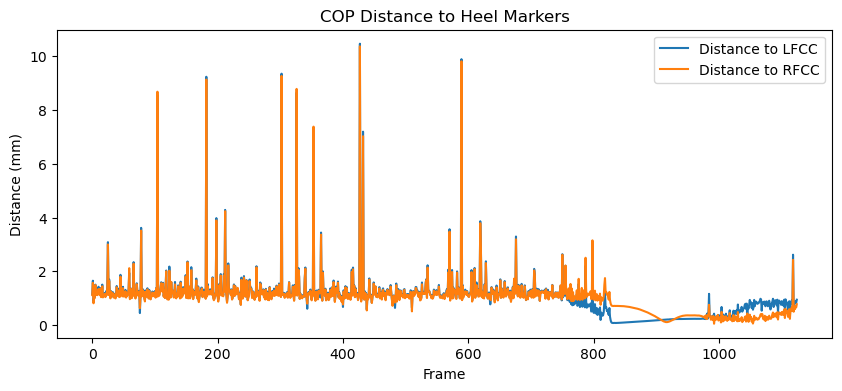

In [7]:
plt.figure(figsize=(10,4))

plt.plot(dist_left, label="Distance to LFCC")
plt.plot(dist_right, label="Distance to RFCC")

plt.xlabel("Frame")
plt.ylabel("Distance (mm)")
plt.title("COP Distance to Heel Markers")
plt.legend()
plt.show()

In [5]:
mean_left, mean_right

(1166.786052840328, 1179.4468718887738)

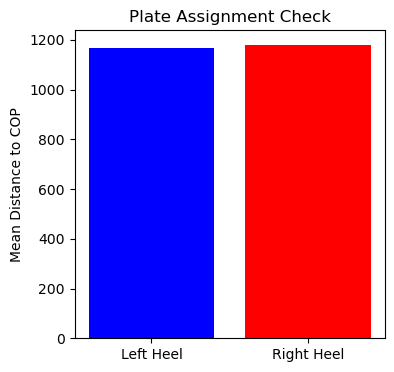

In [6]:
plt.figure(figsize=(4,4))

plt.bar(["Left Heel","Right Heel"], [mean_left, mean_right],
        color=["blue","red"])

plt.ylabel("Mean Distance to COP")
plt.title("Plate Assignment Check")

plt.show()

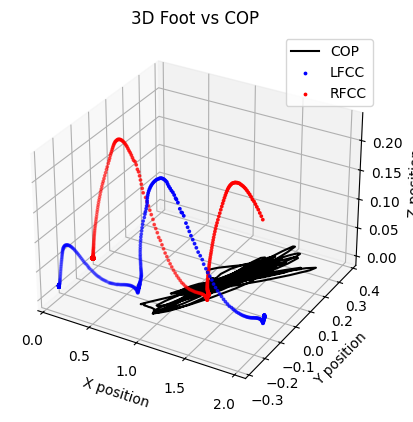

In [13]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(cop[:,0], cop[:,2], cop[:,1], label="COP", color="black")
ax.scatter(lfcc[:,0], lfcc[:,2], lfcc[:,1], color="blue", s=3, label="LFCC")
ax.scatter(rfcc[:,0], rfcc[:,2], rfcc[:,1], color="red", s=3, label="RFCC")

ax.set_title("3D Foot vs COP")
ax.set_xlabel("X position")
ax.set_ylabel("Y position")
ax.set_zlabel("Z position")
ax.legend()

plt.show()

In [17]:
cop

array([[901., 200.,   0.],
       [901., 200.,   0.],
       [901., 200.,   0.],
       ...,
       [901., 200.,   0.],
       [901., 200.,   0.],
       [901., 200.,   0.]])

for only those fram where fy > 20kn

Plate belongs to: Right Foot


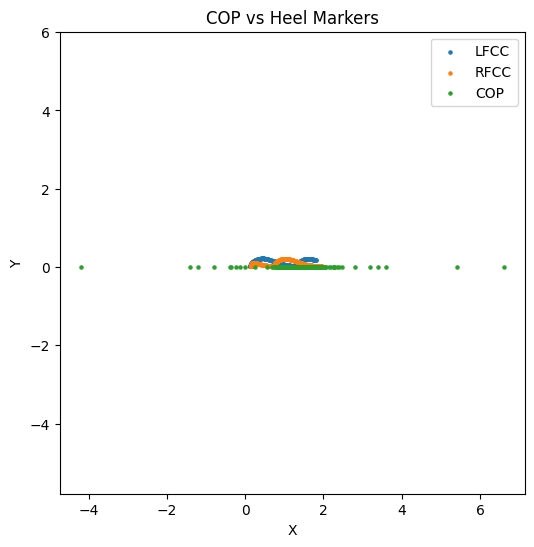

C:\Users\Ritesh Aditya\AppData\Local\Temp\ipykernel_15020\1348771344.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


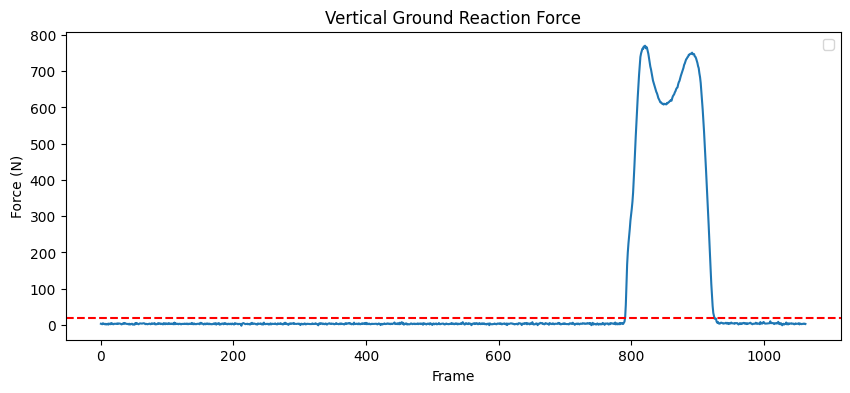

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

trc_file = "stw1.trc"
mot_file = "stw1.mot"

trc_start = 6
mot_start = 0

trc = pd.read_csv(trc_file, sep="\t", skiprows=trc_start)

# ---------- READ MOT ----------
with open(mot_file) as f:
    for i, line in enumerate(f):
        if "endheader" in line.lower():
            mot_start = i + 1
            break

mot = pd.read_csv(mot_file, sep="\t", skiprows=mot_start)

# ---------- EXTRACT HEEL MARKERS ----------
rfcc = trc.iloc[:,74:77].to_numpy()
lfcc = trc.iloc[:,86:89].to_numpy()

# ---------- EXTRACT COP ----------
cop = mot[["ground_force_2_px","ground_force_2_py","ground_force_2_pz"]].to_numpy()

# downsample GRF if higher frequency
cop = cop[::5]

# ---------- EXTRACT VERTICAL FORCE ----------
fz = mot["ground_force_2_vy"].to_numpy()
fz = fz[::5]

# match frame counts
min_frames = min(len(cop), len(rfcc))
cop = cop[:min_frames]
rfcc = rfcc[:min_frames]
lfcc = lfcc[:min_frames]
fz = fz[:min_frames]

# ---------- DETECT STANCE FRAMES ----------
threshold = 20  # Newton
stance = fz > threshold

cop_stance = cop[stance]
rfcc_stance = rfcc[stance]
lfcc_stance = lfcc[stance]

# ---------- COMPUTE DISTANCES ----------
dist_left = np.linalg.norm(cop_stance - lfcc_stance, axis=1)
dist_right = np.linalg.norm(cop_stance - rfcc_stance, axis=1)

mean_left = np.mean(dist_left)
mean_right = np.mean(dist_right)

# ---------- ASSIGN PLATE ----------
if mean_left < mean_right:
    plate_owner = "Left Foot"
else:
    plate_owner = "Right Foot"

print("Plate belongs to:", plate_owner)

# ---------- PLOT COP VS HEELS ----------
plt.figure(figsize=(6,6))

plt.scatter(lfcc[:,0], lfcc[:,1], s=5, label="LFCC")
plt.scatter(rfcc[:,0], rfcc[:,1], s=5, label="RFCC")
plt.scatter(cop[:,0], cop[:,1], s=5, label="COP")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("COP vs Heel Markers")
plt.legend()
plt.axis("equal")
plt.show()

# ---------- PLOT VERTICAL FORCE ----------
plt.figure(figsize=(10,4))
plt.plot(fz)
plt.axhline(threshold, color="red", linestyle="--")
plt.title("Vertical Ground Reaction Force")
plt.xlabel("Frame")
plt.ylabel("Force (N)")
plt.legend()
plt.show()

better version - directly using trc and mot files insttead of c3d

Plate belongs to: Right Foot


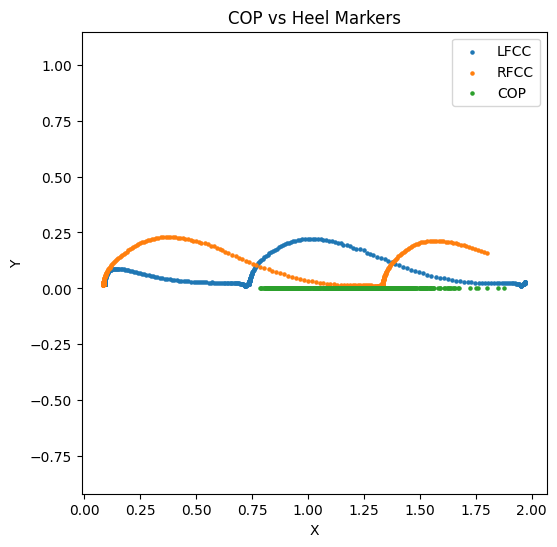

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

trc_file = "stw1.trc"
mot_file = "stw1_filtered.mot"

trc_start = 6
mot_start = 0




trc = pd.read_csv(trc_file, sep="\t", skiprows=trc_start,header = None)

# ---------- READ MOT ----------
with open(mot_file) as f:
    for i, line in enumerate(f):
        if "endheader" in line.lower():
            mot_start = i + 1
            break

mot = pd.read_csv(mot_file, sep="\t", skiprows=mot_start)

# ---------- EXTRACT MARKERS ----------
rfcc = trc.iloc[:,74:77].to_numpy()
lfcc = trc.iloc[:,86:89].to_numpy()

# ---------- EXTRACT COP ----------
cop = mot[["ground_force_2_px","ground_force_2_py","ground_force_2_pz"]].to_numpy()

# downsample if GRF sampled faster
cop = cop[::5]

# ensure same length
min_frames = min(len(cop), len(rfcc))
cop = cop[:min_frames]
rfcc = rfcc[:min_frames]
lfcc = lfcc[:min_frames]

# ---------- COMPUTE DISTANCES ----------
dist_left = np.linalg.norm(cop - lfcc, axis=1)
dist_right = np.linalg.norm(cop - rfcc, axis=1)

mean_left = np.mean(dist_left)
mean_right = np.mean(dist_right)

# ---------- ASSIGN PLATE ----------
if mean_left < mean_right:
    plate_owner = "Left Foot"
else:
    plate_owner = "Right Foot"

print("Plate belongs to:", plate_owner)

# ---------- VISUALIZATION ----------
plt.figure(figsize=(6,6))

plt.scatter(lfcc[:,0], lfcc[:,1], s=5, label="LFCC")
plt.scatter(rfcc[:,0], rfcc[:,1], s=5, label="RFCC")
plt.scatter(cop[:,0], cop[:,1], s=5, label="COP")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("COP vs Heel Markers")
plt.legend()
plt.axis("equal")
plt.show()

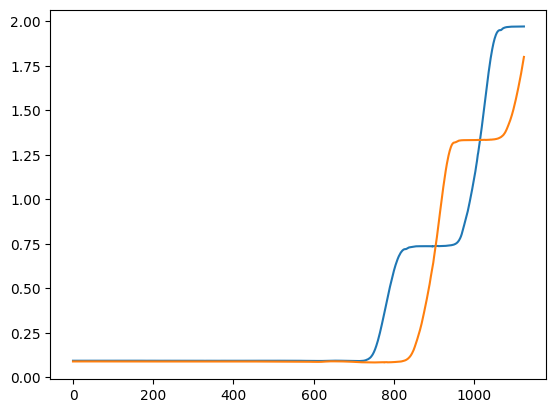

In [9]:
plt.plot(lfcc[:,0], label="LFCC X")
plt.plot(rfcc[:,0], label="RFCC X")

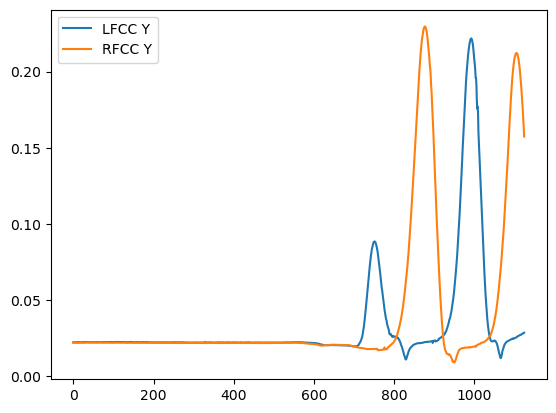

In [4]:
plt.plot(lfcc[:,1], label="LFCC Y")
plt.plot(rfcc[:,1], label="RFCC Y")
plt.legend()

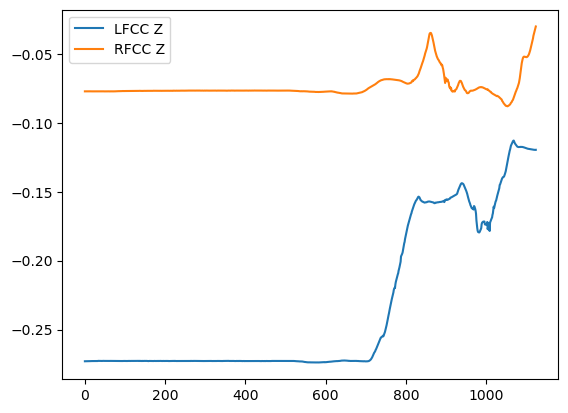

In [5]:
plt.plot(lfcc[:,2], label="LFCC Z")
plt.plot(rfcc[:,2], label="RFCC Z")
plt.legend()

In [7]:
cop = mot[["ground_force_3_px","ground_force_3_py","ground_force_3_pz"]].to_numpy()

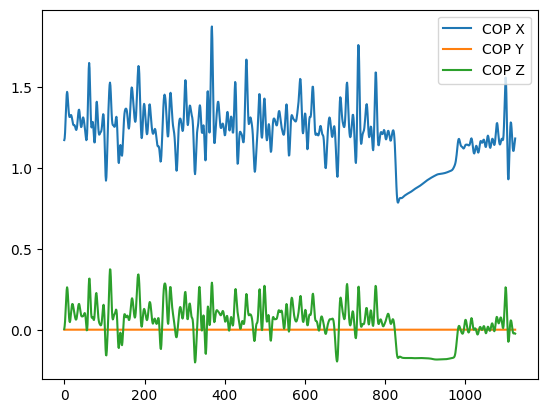

In [10]:
plt.plot(cop[:,0], label="COP X")
plt.plot(cop[:,1], label="COP Y")
plt.plot(cop[:,2], label="COP Z")
plt.legend()

low pass filter

In [9]:
from scipy.signal import butter, filtfilt

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    wn = cutoff / nyq
    b, a = butter(order, wn, btype='low')
    return filtfilt(b, a, data, axis=0)

filtering grf

Saved filtered .mot to: stw1_filtered.mot


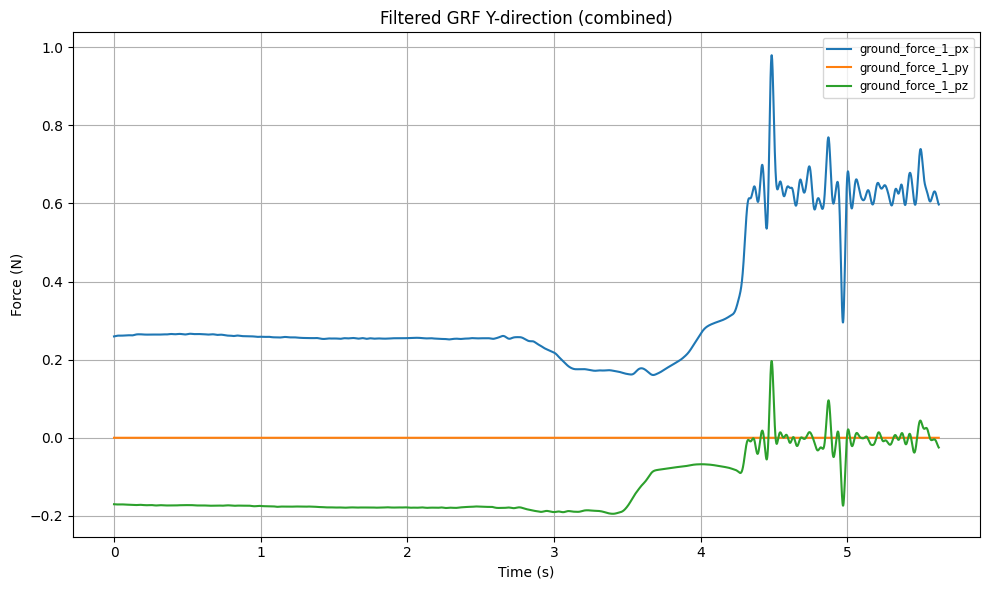

In [21]:
import re
import os
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

def read_mot_with_header(path):
    with open(path, 'r') as f:
        lines = f.readlines()
    # find endheader index
    header_idx = next((i for i,l in enumerate(lines) if 'endheader' in l.lower()), None)
    if header_idx is None:
        raise ValueError("No 'endheader' found in file")
    header_lines = lines[:header_idx+1]      # include the 'endheader' line
    colnames_line = lines[header_idx+1].rstrip("\n")
    # load data (pandas will use the next line as column names)
    df = pd.read_csv(path, sep=r'\s+', engine='python', skiprows=header_idx+1)
    return header_lines, colnames_line, df

def detect_y_columns(df):
    cols = []
    for c in df.columns:
        low = c.lower()
        if re.search(r'(_vy$|_fy$|vy$|fy$)', low) or ('ground_force' in low and 'vy' in low):
            cols.append(c)
    return cols

def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    wn = cutoff / nyq
    b, a = butter(order, wn, btype='low')
    return filtfilt(b, a, data, axis=0)

def filter_and_save_mot(in_path,
                        out_path=None,
                        cutoff=10.0,
                        order=6,
                        fs=None,
                        fs_fallback=1000.0,
                        columns=["ground_force_1_px","ground_force_1_py","ground_force_1_pz"],
                        plot=False):
    """
    Read `in_path` (.mot/.sto), low-pass filter Y-GRF columns, and save to `out_path`
    preserving the original header and column-label line.
    If out_path is None, a new file `<inname>_filtered.mot` is created next to input.
    """
    header_lines, colnames_line, df = read_mot_with_header(in_path)

    if columns is None:
        columns = detect_y_columns(df)
    if not columns:
        raise ValueError("No Y-direction GRF columns detected. Provide `columns=` explicitly.")

    # estimate fs if not provided
    time_col = next((c for c in df.columns if c.lower() == 'time'), df.columns[0])
    time = df[time_col].values
    if fs is None:
        if len(time) >= 2:
            dt = np.mean(np.diff(time))
            fs = 1.0 / dt
        else:
            fs = fs_fallback

    # prepare numeric matrix and filter
    data_mat = df.iloc[:,1:].astype(float).values
    filtered_mat = butter_lowpass_filter(data_mat, cutoff=cutoff, fs=fs, order=order)

    # place filtered values back into dataframe copy
    df_filt = df.copy()
    df_filt.iloc[:, 1:] = filtered_mat

    # choose output path
    if out_path is None:
        base, ext = os.path.splitext(in_path)
        out_path = base + '_filtered' + (ext if ext else '.mot')

    # write header + original column label line + filtered data (no pandas header)
    with open(out_path, 'w', newline='\n') as f:
        f.writelines(header_lines)
        f.write(colnames_line + '\n')
    # append data without header (tab-separated for readability)
    df_filt.to_csv(out_path, sep='\t', index=False, header=False, float_format='%.6f', mode='a')
    print(f"Saved filtered .mot to: {out_path}")

    if plot:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10,6))
        for c in columns:
            plt.plot(time, df_filt[c].values, label=c)
        plt.xlabel('Time (s)')
        plt.ylabel('Force (N)')
        plt.title('Filtered GRF Y-direction (combined)')
        plt.legend(fontsize='small')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return df_filt, out_path

# Example usage:
in_mot = r'stw1.mot'
df_filtered, out_file = filter_and_save_mot(in_mot, cutoff=20, order=4, plot=True)